# Main PyTorch Training: BTC 2023 LOB Forecasting

In [70]:
import os
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary
from tqdm.auto import tqdm

In [71]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

bundle_path = os.path.join(os.getcwd(), 'data', 'BTC20230120_clean_1s.pkl')
bundle_metadata = pd.read_pickle(bundle_path)['metadata']
symbol = str(bundle_metadata['symbol'])
print(f"training bundle: {bundle_path}")
print(f"symbol: {symbol}")

target_horizon = 10
sequence_length = 10
batch_size = 128
epochs = 20
learning_rate = 5e-5
weight_decay = 1e-4
model_hidden_size = 32
model_dropout = 0.2
early_stopping_patience = 4
train_frac = 0.60
val_frac = 0.20
checkpoint_path = 'best_val_model_pytorch_btc20230120_return_10s.pt'
plot_points = 1000

return_target_column = 'target_return'
return_objective_name = 'smooth_l1'
directional_loss_weight = 0.15
tail_weight = 0.50
tail_weight_quantile = 0.80
max_gradient_norm = 1.0
use_plateau_scheduler = True
plateau_factor = 0.5
plateau_patience = 2
plateau_min_lr = 1e-6

cuda:0
training bundle: c:\Users\Fabian\Desktop\Machine Learning\MAT629\MATH-629-Project\data\BTC20230120_clean_1s.pkl
symbol: BTC20230120


In [72]:
bundle_preview = pd.read_pickle(bundle_path)
clean_lob_preview = bundle_preview['clean_lob'].copy()
clean_lob_preview['timestamp_utc'] = pd.to_datetime(clean_lob_preview['timestamp_utc'], utc=True)

print(bundle_preview['metadata'])
print(clean_lob_preview[['timestamp_utc', 'symbol', 'ask_price_1', 'ask_size_1', 'bid_price_1', 'bid_size_1']].head())


{'source_file': 'C:\\Users\\Fabian\\Desktop\\Machine Learning\\MAT629\\MATH-629-Project\\data\\Tardis_sample_data\\BTC20230120.csv', 'source_format': 'flat_fi2010_export', 'exchange': 'flat_csv_export', 'symbol': 'BTC20230120', 'time_zone': 'UTC', 'input_timestamp_unit': 'milliseconds', 'chosen_frequency': '1s', 'recommended_frequency': '1s', 'depth_levels': 10, 'feature_columns': ['ask_price_1', 'ask_size_1', 'bid_price_1', 'bid_size_1', 'ask_price_2', 'ask_size_2', 'bid_price_2', 'bid_size_2', 'ask_price_3', 'ask_size_3', 'bid_price_3', 'bid_size_3', 'ask_price_4', 'ask_size_4', 'bid_price_4', 'bid_size_4', 'ask_price_5', 'ask_size_5', 'bid_price_5', 'bid_size_5', 'ask_price_6', 'ask_size_6', 'bid_price_6', 'bid_size_6', 'ask_price_7', 'ask_size_7', 'bid_price_7', 'bid_size_7', 'ask_price_8', 'ask_size_8', 'bid_price_8', 'bid_size_8', 'ask_price_9', 'ask_size_9', 'bid_price_9', 'bid_size_9', 'ask_price_10', 'ask_size_10', 'bid_price_10', 'bid_size_10'], 'clean_start_utc': '2023-01-09

# Data Preparation

We keep the original 10-level FI-2010 order book features and only add a few simple BTC features: `mid_price`, `spread_bps`, `imbalance_l1`, `imbalance_l10`, `depth_total`, `log_return_1`, and `log_return_5`. The target is the `target_horizon`-step future return.


In [73]:
ENGINEERED_FEATURE_COLUMNS = [
    'mid_price',
    'spread_bps',
    'imbalance_l1',
    'imbalance_l10',
    'depth_total',
    'log_return_1',
    'log_return_5',
]


def safe_correlation(left: pd.Series, right: pd.Series) -> float:
    if len(left) < 2 or len(right) < 2:
        return float('nan')
    if left.nunique(dropna=True) <= 1 or right.nunique(dropna=True) <= 1:
        return float('nan')
    return float(left.corr(right))


def engineer_frame(lob_frame: pd.DataFrame, raw_feature_columns: list[str], symbol: str, target_horizon: int) -> tuple[pd.DataFrame, list[str]]:
    frame = lob_frame.loc[lob_frame['symbol'] == symbol].copy()
    frame = frame.sort_values('timestamp_utc').reset_index(drop=True)
    frame['timestamp_utc'] = pd.to_datetime(frame['timestamp_utc'], utc=True)

    best_ask = frame['ask_price_1']
    best_bid = frame['bid_price_1']
    bid_size_columns = [f'bid_size_{level}' for level in range(1, 11)]
    ask_size_columns = [f'ask_size_{level}' for level in range(1, 11)]

    bid_depth_total = frame[bid_size_columns].sum(axis=1)
    ask_depth_total = frame[ask_size_columns].sum(axis=1)
    total_depth = bid_depth_total + ask_depth_total
    top_depth = frame['bid_size_1'] + frame['ask_size_1']

    frame['mid_price'] = (best_ask + best_bid) / 2.0
    frame['spread_bps'] = np.where(frame['mid_price'] != 0, 10_000.0 * (best_ask - best_bid) / frame['mid_price'], 0.0)
    frame['imbalance_l1'] = np.where(top_depth != 0, (frame['bid_size_1'] - frame['ask_size_1']) / top_depth, 0.0)
    frame['imbalance_l10'] = np.where(total_depth != 0, (bid_depth_total - ask_depth_total) / total_depth, 0.0)
    frame['depth_total'] = total_depth
    frame['log_return_1'] = np.log(frame['mid_price']).diff().fillna(0.0)
    frame['log_return_5'] = np.log(frame['mid_price']).diff(5).fillna(0.0)

    frame['current_mid_price'] = frame['mid_price']
    frame['target_mid_price'] = frame['mid_price'].shift(-target_horizon)
    frame['target_timestamp_utc'] = frame['timestamp_utc'].shift(-target_horizon)
    frame['target_return'] = np.where(
        frame['current_mid_price'] != 0,
        frame['target_mid_price'] / frame['current_mid_price'] - 1.0,
        0.0,
    )
    frame['target_direction'] = np.sign(frame['target_return']).fillna(0.0).astype(np.int64)

    # The improved direction task uses a future average mid-price, not just one timestamp.
    future_mid_terms = [frame['mid_price'].shift(-step) for step in range(1, target_horizon + 1)]
    frame['future_mean_mid_price'] = sum(future_mid_terms) / target_horizon
    frame['smoothed_return'] = np.where(
        frame['current_mid_price'] != 0,
        frame['future_mean_mid_price'] / frame['current_mid_price'] - 1.0,
        0.0,
    )

    feature_columns = raw_feature_columns + ENGINEERED_FEATURE_COLUMNS
    keep_columns = [
        'symbol',
        'timestamp_utc',
        'target_timestamp_utc',
        'current_mid_price',
        'target_mid_price',
        'future_mean_mid_price',
        'target_return',
        'smoothed_return',
        'target_direction',
        *feature_columns,
    ]
    engineered = frame[keep_columns].dropna().reset_index(drop=True)
    return engineered, feature_columns


def split_by_time(frame: pd.DataFrame, train_frac: float, val_frac: float, purge_rows: int) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    n_rows = len(frame)
    train_end = int(np.floor(n_rows * train_frac))
    val_end = int(np.floor(n_rows * (train_frac + val_frac)))

    train_stop = max(1, train_end - purge_rows)
    val_start = train_end
    val_stop = max(val_start + 1, val_end - purge_rows)

    train_frame = frame.iloc[:train_stop].reset_index(drop=True)
    val_frame = frame.iloc[val_start:val_stop].reset_index(drop=True)
    test_frame = frame.iloc[val_end:].reset_index(drop=True)

    if min(len(train_frame), len(val_frame), len(test_frame)) <= sequence_length:
        raise ValueError('At least one split is too small for the chosen sequence length.')
    return train_frame, val_frame, test_frame


def assert_no_target_leak(train_frame: pd.DataFrame, val_frame: pd.DataFrame, test_frame: pd.DataFrame) -> None:
    train_last_target = pd.Timestamp(train_frame['target_timestamp_utc'].max())
    val_first_timestamp = pd.Timestamp(val_frame['timestamp_utc'].min())
    val_last_target = pd.Timestamp(val_frame['target_timestamp_utc'].max())
    test_first_timestamp = pd.Timestamp(test_frame['timestamp_utc'].min())

    if train_last_target >= val_first_timestamp:
        raise ValueError('Train targets leak into validation.')
    if val_last_target >= test_first_timestamp:
        raise ValueError('Validation targets leak into test.')


def fit_standardizer(train_frame: pd.DataFrame, feature_columns: list[str], target_column: str) -> dict[str, object]:
    feature_mean = train_frame[feature_columns].mean()
    feature_std = train_frame[feature_columns].std(ddof=0).replace(0.0, 1.0)
    target_mean = float(train_frame[target_column].mean())
    target_std = float(train_frame[target_column].std(ddof=0))
    if target_std == 0.0:
        target_std = 1.0
    return {
        'feature_mean': feature_mean,
        'feature_std': feature_std,
        'target_mean': target_mean,
        'target_std': target_std,
    }


def apply_standardizer(frame: pd.DataFrame, standardizer: dict[str, object], feature_columns: list[str], target_column: str) -> pd.DataFrame:
    scaled = frame.copy()
    scaled[feature_columns] = (scaled[feature_columns] - standardizer['feature_mean']) / standardizer['feature_std']
    scaled['target_scaled'] = (scaled[target_column] - standardizer['target_mean']) / standardizer['target_std']
    return scaled


def build_sequences(frame: pd.DataFrame, feature_columns: list[str], sequence_length: int) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    if len(frame) < sequence_length:
        raise ValueError('Frame is shorter than the sequence length.')

    feature_array = frame[feature_columns].to_numpy(dtype=np.float32)
    target_array = frame['target_scaled'].to_numpy(dtype=np.float32)
    sample_count = len(frame) - sequence_length + 1

    x = np.zeros((sample_count, sequence_length, len(feature_columns)), dtype=np.float32)
    y = np.zeros(sample_count, dtype=np.float32)
    metadata_rows = []

    for end_index in range(sequence_length - 1, len(frame)):
        sample_index = end_index - sequence_length + 1
        x[sample_index] = feature_array[sample_index:end_index + 1]
        y[sample_index] = target_array[end_index]
        row = frame.iloc[end_index]
        metadata_rows.append({
            'symbol': row['symbol'],
            'timestamp_utc': row['timestamp_utc'],
            'target_timestamp_utc': row['target_timestamp_utc'],
            'current_mid_price': float(row['current_mid_price']),
            'target_mid_price': float(row['target_mid_price']),
            'target_return': float(row['target_return']),
            'smoothed_return': float(row['smoothed_return']),
            'target_direction': float(row['target_direction']),
        })

    metadata = pd.DataFrame(metadata_rows)
    return x, y, metadata


class LOBSequenceDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray, metadata: pd.DataFrame):
        self.x = torch.from_numpy(x).float().unsqueeze(1)
        self.y = torch.from_numpy(y).float()
        self.metadata = metadata.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.x)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.x[index], self.y[index]


@dataclass
class SequenceBundle:
    train_dataset: LOBSequenceDataset
    val_dataset: LOBSequenceDataset
    test_dataset: LOBSequenceDataset
    train_loader: DataLoader
    val_loader: DataLoader
    test_loader: DataLoader
    feature_columns: list[str]
    raw_splits: dict[str, pd.DataFrame]
    scaled_splits: dict[str, pd.DataFrame]
    standardizer: dict[str, object]
    target_horizon: int
    sequence_length: int
    target_column: str


def build_sequence_bundle(
    bundle_path: str,
    symbol: str,
    target_horizon: int,
    sequence_length: int,
    batch_size: int,
    train_frac: float,
    val_frac: float,
    target_column: str = 'target_return',
) -> SequenceBundle:
    pickle_bundle = pd.read_pickle(bundle_path)
    lob_frame = pickle_bundle['clean_lob'].copy()
    raw_feature_columns = list(pickle_bundle['metadata']['feature_columns'])

    engineered_frame, feature_columns = engineer_frame(lob_frame, raw_feature_columns, symbol, target_horizon)
    train_frame, val_frame, test_frame = split_by_time(engineered_frame, train_frac, val_frac, purge_rows=target_horizon)
    assert_no_target_leak(train_frame, val_frame, test_frame)

    standardizer = fit_standardizer(train_frame, feature_columns, target_column)
    scaled_train = apply_standardizer(train_frame, standardizer, feature_columns, target_column)
    scaled_val = apply_standardizer(val_frame, standardizer, feature_columns, target_column)
    scaled_test = apply_standardizer(test_frame, standardizer, feature_columns, target_column)

    train_x, train_y, train_meta = build_sequences(scaled_train, feature_columns, sequence_length)
    val_x, val_y, val_meta = build_sequences(scaled_val, feature_columns, sequence_length)
    test_x, test_y, test_meta = build_sequences(scaled_test, feature_columns, sequence_length)

    train_dataset = LOBSequenceDataset(train_x, train_y, train_meta)
    val_dataset = LOBSequenceDataset(val_x, val_y, val_meta)
    test_dataset = LOBSequenceDataset(test_x, test_y, test_meta)

    return SequenceBundle(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
        train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        val_loader=DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
        test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False),
        feature_columns=feature_columns,
        raw_splits={'train': train_frame, 'val': val_frame, 'test': test_frame},
        scaled_splits={'train': scaled_train, 'val': scaled_val, 'test': scaled_test},
        standardizer=standardizer,
        target_horizon=target_horizon,
        sequence_length=sequence_length,
        target_column=target_column,
    )


In [74]:
data_bundle = build_sequence_bundle(
    bundle_path=bundle_path,
    symbol=symbol,
    target_horizon=target_horizon,
    sequence_length=sequence_length,
    batch_size=batch_size,
    train_frac=train_frac,
    val_frac=val_frac,
    target_column=return_target_column,
)

split_summary = pd.DataFrame([
    {
        'split': split_name,
        'rows': len(frame),
        'sequences': len(getattr(data_bundle, f'{split_name}_dataset')),
        'start_utc': frame['timestamp_utc'].min(),
        'end_utc': frame['timestamp_utc'].max(),
        'target_start_utc': frame['target_timestamp_utc'].min(),
        'target_end_utc': frame['target_timestamp_utc'].max(),
    }
    for split_name, frame in data_bundle.raw_splits.items()
])

scaled_train = data_bundle.scaled_splits['train'][data_bundle.feature_columns]
scaled_val = data_bundle.scaled_splits['val'][data_bundle.feature_columns]
scaled_test = data_bundle.scaled_splits['test'][data_bundle.feature_columns]
standardization_summary = pd.DataFrame([
    {
        'split': 'train',
        'feature_mean_abs': float(scaled_train.mean().abs().mean()),
        'feature_std_mean': float(scaled_train.std(ddof=0).mean()),
    },
    {
        'split': 'val',
        'feature_mean_abs': float(scaled_val.mean().abs().mean()),
        'feature_std_mean': float(scaled_val.std(ddof=0).mean()),
    },
    {
        'split': 'test',
        'feature_mean_abs': float(scaled_test.mean().abs().mean()),
        'feature_std_mean': float(scaled_test.std(ddof=0).mean()),
    },
])

print(split_summary)
print(standardization_summary)
print(f'feature_dim={len(data_bundle.feature_columns)}')
print(f'target_column={data_bundle.target_column}')
print(f'target_mean={data_bundle.standardizer["target_mean"]:.8f}')
print(f'target_std={data_bundle.standardizer["target_std"]:.8f}')
print(data_bundle.feature_columns[-len(ENGINEERED_FEATURE_COLUMNS):])


   split    rows  sequences                 start_utc  \
0  train  561102     561093 2023-01-09 22:17:40+00:00   
1    val  187028     187019 2023-01-16 10:13:53+00:00   
2   test  187038     187029 2023-01-18 14:12:14+00:00   

                    end_utc          target_start_utc  \
0 2023-01-16 10:13:42+00:00 2023-01-09 22:17:50+00:00   
1 2023-01-18 14:12:03+00:00 2023-01-16 10:14:03+00:00   
2 2023-01-20 18:10:38+00:00 2023-01-18 14:12:24+00:00   

             target_end_utc  
0 2023-01-16 10:13:52+00:00  
1 2023-01-18 14:12:13+00:00  
2 2023-01-20 18:10:48+00:00  
   split  feature_mean_abs  feature_std_mean
0  train      8.723193e-16          1.000000
1    val      7.110546e-01          0.435104
2   test      6.024620e-01          0.485539
feature_dim=47
target_column=target_return
target_mean=0.00000353
target_std=0.00033859
['mid_price', 'spread_bps', 'imbalance_l1', 'imbalance_l10', 'depth_total', 'log_return_1', 'log_return_5']


# Model

The backbone stays close to DeepLOB. The only modeling change here is the target: the network predicts standardized future return instead of a future mid-price level.


In [75]:
class DeepLOBRegressor(nn.Module):
    def __init__(self, feature_dim: int, hidden_size: int = 32, dropout_rate: float = 0.2):
        super().__init__()

        width_after_conv1 = ((feature_dim - 2) // 2) + 1
        width_after_conv2 = ((width_after_conv1 - 2) // 2) + 1
        if width_after_conv2 < 1:
            raise ValueError(f'feature_dim={feature_dim} is too small for the DeepLOB backbone.')

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(1, 2), stride=(1, 2)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1, 2), stride=(1, 2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4, 1), padding='same'),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4, 1), padding='same'),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1, width_after_conv2)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.inp1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(5, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.lstm = nn.LSTM(input_size=192, hidden_size=hidden_size, num_layers=1, batch_first=True)
        # A smaller head plus dropout is the first regularization step before bigger label changes.
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h0 = torch.zeros(1, x.size(0), self.lstm.hidden_size, device=x.device)
        c0 = torch.zeros(1, x.size(0), self.lstm.hidden_size, device=x.device)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        x_inp1 = self.inp1(x)
        x_inp2 = self.inp2(x)
        x_inp3 = self.inp3(x)

        x = torch.cat((x_inp1, x_inp2, x_inp3), dim=1)
        x = x.permute(0, 2, 1, 3)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))
        x, _ = self.lstm(x, (h0, c0))
        x = x[:, -1, :]
        x = self.dropout(x)
        return self.fc(x).squeeze(-1)


class WeightedDirectionalSmoothL1Loss(nn.Module):
    def __init__(self, directional_loss_weight: float = 0.15, tail_weight: float = 0.50, tail_quantile: float = 0.80):
        super().__init__()
        self.directional_loss_weight = directional_loss_weight
        self.tail_weight = tail_weight
        self.tail_quantile = tail_quantile

    def forward(self, predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        weights = torch.ones_like(targets)
        if self.tail_weight > 0.0 and targets.numel() > 1:
            tail_threshold = torch.quantile(targets.detach().abs(), self.tail_quantile)
            weights = weights + self.tail_weight * (targets.abs() >= tail_threshold).float()

        regression_loss = (weights * F.smooth_l1_loss(predictions, targets, reduction='none')).mean()
        if self.directional_loss_weight <= 0.0:
            return regression_loss

        direction_targets = (targets >= 0).float()
        direction_loss = F.binary_cross_entropy_with_logits(predictions, direction_targets, weight=weights)
        return regression_loss + self.directional_loss_weight * direction_loss


def build_return_objective(
    objective_name: str,
    directional_loss_weight: float,
    tail_weight: float,
    tail_quantile: float,
) -> nn.Module:
    if objective_name == 'smooth_l1':
        return nn.SmoothL1Loss()
    if objective_name == 'weighted_directional':
        return WeightedDirectionalSmoothL1Loss(
            directional_loss_weight=directional_loss_weight,
            tail_weight=tail_weight,
            tail_quantile=tail_quantile,
        )
    raise ValueError(f'Unsupported objective_name={objective_name}')


def build_plateau_scheduler(
    optimizer: torch.optim.Optimizer,
    use_scheduler: bool,
    factor: float,
    patience: int,
    min_lr: float,
):
    if not use_scheduler:
        return None
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=factor,
        patience=patience,
        min_lr=min_lr,
    )


def train_model(
    model: nn.Module,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    epochs: int,
    checkpoint_path: str,
    early_stopping_patience: int,
    scheduler=None,
    max_gradient_norm: float | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    train_losses: list[float] = []
    val_losses: list[float] = []
    best_val_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in tqdm(range(epochs)):
        model.train()
        epoch_train_losses = []
        for inputs, targets in train_loader:
            inputs = inputs.to(device, dtype=torch.float32)
            targets = targets.to(device, dtype=torch.float32)

            optimizer.zero_grad(set_to_none=True)
            predictions = model(inputs)
            loss = criterion(predictions, targets)
            loss.backward()
            if max_gradient_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_gradient_norm)
            optimizer.step()
            epoch_train_losses.append(loss.item())

        model.eval()
        epoch_val_losses = []
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device, dtype=torch.float32)
                targets = targets.to(device, dtype=torch.float32)
                predictions = model(inputs)
                loss = criterion(predictions, targets)
                epoch_val_losses.append(loss.item())

        train_loss = float(np.mean(epoch_train_losses))
        val_loss = float(np.mean(epoch_val_losses))
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                break

    return np.asarray(train_losses, dtype=np.float64), np.asarray(val_losses, dtype=np.float64)


def load_best_checkpoint(model: nn.Module, checkpoint_path: str, device: torch.device) -> nn.Module:
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device)
    return model


def predict_scaled(model: nn.Module, loader: DataLoader, device: torch.device) -> np.ndarray:
    model.eval()
    predictions = []
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device, dtype=torch.float32)
            batch_predictions = model(inputs).detach().cpu().numpy()
            predictions.append(batch_predictions)
    return np.concatenate(predictions)


def make_prediction_frame(model: nn.Module, dataset: LOBSequenceDataset, standardizer: dict[str, object], device: torch.device, target_column: str = 'target_return') -> pd.DataFrame:
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    scaled_predictions = predict_scaled(model, loader, device)
    frame = dataset.metadata.copy()
    frame['predicted_target_value'] = scaled_predictions * standardizer['target_std'] + standardizer['target_mean']
    frame['predicted_return'] = frame['predicted_target_value']
    frame['prediction_target'] = frame[target_column]
    frame['predicted_mid_price'] = frame['current_mid_price'] * (1.0 + frame['predicted_target_value'])
    frame['prediction_error'] = frame['predicted_target_value'] - frame[target_column]
    frame['predicted_direction'] = np.sign(frame['predicted_target_value']).astype(np.float32)
    return frame


def evaluate_return_predictions(prediction_frame: pd.DataFrame, target_column: str = 'target_return') -> pd.DataFrame:
    model_error = prediction_frame['predicted_target_value'] - prediction_frame[target_column]
    persistence_error = -prediction_frame[target_column]
    return pd.DataFrame([
        {
            'target_column': target_column,
            'return_mae_bps': float(np.mean(np.abs(model_error)) * 10_000.0),
            'return_rmse_bps': float(np.sqrt(np.mean(np.square(model_error))) * 10_000.0),
            'persistence_return_rmse_bps': float(np.sqrt(np.mean(np.square(persistence_error))) * 10_000.0),
            'rmse_gain_vs_persistence_bps': float((np.sqrt(np.mean(np.square(persistence_error))) - np.sqrt(np.mean(np.square(model_error)))) * 10_000.0),
            'return_ic': safe_correlation(prediction_frame['predicted_target_value'], prediction_frame[target_column]),
            'direction_accuracy': float(np.mean(prediction_frame['predicted_direction'] == np.sign(prediction_frame[target_column]))),
        }
    ])


def plot_loss_curves(train_losses: np.ndarray, val_losses: np.ndarray, title: str = 'DeepLOB training loss') -> None:
    plt.figure(figsize=(12, 4))
    plt.plot(train_losses, label='train loss')
    plt.plot(val_losses, label='validation loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()


def plot_return_predictions(prediction_frame: pd.DataFrame, points: int = 1000, target_column: str = 'target_return') -> None:
    frame = prediction_frame.sort_values('timestamp_utc').tail(points).copy()
    actual_bps = frame[target_column].to_numpy(dtype=np.float64) * 10_000.0
    predicted_bps = frame['predicted_target_value'].to_numpy(dtype=np.float64) * 10_000.0
    clip_value = float(np.nanquantile(np.abs(np.concatenate([actual_bps, predicted_bps])), 0.99))

    plt.figure(figsize=(14, 4))
    plt.plot(frame['timestamp_utc'], actual_bps, label=f'actual {target_column}', linewidth=1.6)
    plt.plot(frame['timestamp_utc'], predicted_bps, label='predicted target', linewidth=1.2)
    plt.axhline(0.0, color='black', linestyle='--', linewidth=1)
    if np.isfinite(clip_value) and clip_value > 0:
        plt.ylim(-clip_value, clip_value)
    plt.xlabel('UTC timestamp')
    plt.ylabel('Return (bps)')
    plt.title(f'BTC test {target_column} prediction, last {len(frame)} points')
    plt.legend()
    plt.tight_layout()


In [76]:
DIRECTION_ID_TO_VALUE = np.array([-1, 0, 1], dtype=np.int64)
DIRECTION_NAMES = ['down', 'flat', 'up']


def encode_direction_labels(direction_values: pd.Series | np.ndarray) -> np.ndarray:
    direction_array = np.asarray(direction_values, dtype=np.int64)
    mapping = {-1: 0, 0: 1, 1: 2}
    return np.vectorize(mapping.get)(direction_array).astype(np.int64)


def decode_direction_ids(label_ids: pd.Series | np.ndarray) -> np.ndarray:
    label_array = np.asarray(label_ids, dtype=np.int64)
    return DIRECTION_ID_TO_VALUE[label_array]


def build_classification_sequences(frame: pd.DataFrame, feature_columns: list[str], label_column: str, sequence_length: int) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    feature_array = frame[feature_columns].to_numpy(dtype=np.float32)
    label_array = frame[label_column].to_numpy(dtype=np.int64)
    sample_count = len(frame) - sequence_length + 1

    x = np.zeros((sample_count, sequence_length, len(feature_columns)), dtype=np.float32)
    y = np.zeros(sample_count, dtype=np.int64)
    metadata_rows = []

    for end_index in range(sequence_length - 1, len(frame)):
        sample_index = end_index - sequence_length + 1
        x[sample_index] = feature_array[sample_index:end_index + 1]
        y[sample_index] = label_array[end_index]
        row = frame.iloc[end_index]
        metadata_rows.append({
            'symbol': row['symbol'],
            'timestamp_utc': row['timestamp_utc'],
            'target_timestamp_utc': row['target_timestamp_utc'],
            'current_mid_price': float(row['current_mid_price']),
            'target_mid_price': float(row['target_mid_price']),
            'target_return': float(row['target_return']),
            'target_direction': int(row['direction_value']),
            'label_id': int(row[label_column]),
        })

    metadata = pd.DataFrame(metadata_rows)
    return x, y, metadata


class LOBClassificationDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray, metadata: pd.DataFrame):
        self.x = torch.from_numpy(x).float().unsqueeze(1)
        self.y = torch.from_numpy(y).long()
        self.metadata = metadata.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.x)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.x[index], self.y[index]


class DeepLOBClassifier(DeepLOBRegressor):
    def __init__(self, feature_dim: int, hidden_size: int = 32, dropout_rate: float = 0.2, num_classes: int = 3):
        super().__init__(feature_dim=feature_dim, hidden_size=hidden_size, dropout_rate=dropout_rate)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h0 = torch.zeros(1, x.size(0), self.lstm.hidden_size, device=x.device)
        c0 = torch.zeros(1, x.size(0), self.lstm.hidden_size, device=x.device)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        x_inp1 = self.inp1(x)
        x_inp2 = self.inp2(x)
        x_inp3 = self.inp3(x)

        x = torch.cat((x_inp1, x_inp2, x_inp3), dim=1)
        x = x.permute(0, 2, 1, 3)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))
        x, _ = self.lstm(x, (h0, c0))
        x = x[:, -1, :]
        x = self.dropout(x)
        return self.fc(x)


def compute_macro_f1_from_ids(true_ids: np.ndarray, pred_ids: np.ndarray) -> float:
    confusion = np.zeros((3, 3), dtype=np.float64)
    for true_id, pred_id in zip(true_ids, pred_ids):
        confusion[true_id, pred_id] += 1.0

    precision = np.divide(np.diag(confusion), confusion.sum(axis=0), out=np.zeros(3, dtype=np.float64), where=confusion.sum(axis=0) != 0)
    recall = np.divide(np.diag(confusion), confusion.sum(axis=1), out=np.zeros(3, dtype=np.float64), where=confusion.sum(axis=1) != 0)
    f1 = np.divide(2.0 * precision * recall, precision + recall, out=np.zeros(3, dtype=np.float64), where=(precision + recall) != 0)
    return float(f1.mean())


def train_classification_model(
    model: nn.Module,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    epochs: int,
    checkpoint_path: str,
    early_stopping_patience: int,
) -> tuple[np.ndarray, np.ndarray]:
    train_losses: list[float] = []
    val_losses: list[float] = []
    best_val_loss = float('inf')
    best_macro_f1 = -np.inf
    epochs_without_improvement = 0

    for epoch in tqdm(range(epochs)):
        model.train()
        epoch_train_losses = []
        for inputs, targets in train_loader:
            inputs = inputs.to(device, dtype=torch.float32)
            targets = targets.to(device, dtype=torch.long)

            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            epoch_train_losses.append(loss.item())

        model.eval()
        epoch_val_losses = []
        val_true_ids = []
        val_pred_ids = []
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device, dtype=torch.float32)
                targets = targets.to(device, dtype=torch.long)
                logits = model(inputs)
                loss = criterion(logits, targets)
                epoch_val_losses.append(loss.item())
                val_true_ids.append(targets.detach().cpu().numpy())
                val_pred_ids.append(logits.argmax(dim=1).detach().cpu().numpy())

        train_loss = float(np.mean(epoch_train_losses))
        val_loss = float(np.mean(epoch_val_losses))
        val_macro_f1 = compute_macro_f1_from_ids(np.concatenate(val_true_ids), np.concatenate(val_pred_ids))
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Select the best direction model by macro F1 so flat-majority behavior does not win on loss alone.
        improved = (val_macro_f1 > best_macro_f1 + 1e-6) or (np.isclose(val_macro_f1, best_macro_f1) and val_loss < best_val_loss)
        if improved:
            best_macro_f1 = val_macro_f1
            best_val_loss = val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                break

    return np.asarray(train_losses, dtype=np.float64), np.asarray(val_losses, dtype=np.float64)


def predict_classification(model: nn.Module, loader: DataLoader, device: torch.device) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    logits_batches = []
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device, dtype=torch.float32)
            logits_batches.append(model(inputs).detach().cpu().numpy())
    logits = np.concatenate(logits_batches)
    probabilities = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
    predicted_ids = probabilities.argmax(axis=1)
    return probabilities, predicted_ids


def compute_class_weights(label_ids: np.ndarray) -> np.ndarray:
    counts = np.bincount(label_ids, minlength=3).astype(np.float64)
    weights = 1.0 / np.sqrt(np.maximum(counts, 1.0))
    return weights / weights.mean()


def build_direction_bundle(data_bundle: SequenceBundle, label_mode: str, batch_size: int, threshold_multiplier: float = 0.5) -> dict[str, object]:
    raw_splits = {name: frame.copy() for name, frame in data_bundle.raw_splits.items()}
    scaled_splits = {name: frame.copy() for name, frame in data_bundle.scaled_splits.items()}

    if label_mode == 'naive':
        threshold = None
        for split_name in raw_splits:
            raw_splits[split_name]['direction_value'] = raw_splits[split_name]['target_direction'].astype(np.int64)
    elif label_mode == 'improved':
        train_spread_return = float((raw_splits['train']['spread_bps'] / 10_000.0).median())
        threshold = float(threshold_multiplier * train_spread_return)
        for split_name in raw_splits:
            split_frame = raw_splits[split_name]
            # Trick: keep a small dead-zone so tiny moves stay flat.
            split_frame['direction_value'] = np.where(
                split_frame['smoothed_return'] > threshold,
                1,
                np.where(split_frame['smoothed_return'] < -threshold, -1, 0),
            ).astype(np.int64)
    else:
        raise ValueError("label_mode must be 'naive' or 'improved'.")

    for split_name in scaled_splits:
        scaled_splits[split_name]['direction_value'] = raw_splits[split_name]['direction_value'].to_numpy(dtype=np.int64)
        scaled_splits[split_name]['label_id'] = encode_direction_labels(scaled_splits[split_name]['direction_value'])

    train_label_ids = scaled_splits['train']['label_id'].to_numpy(dtype=np.int64)
    class_weights = compute_class_weights(train_label_ids)
    class_distribution = pd.Series(decode_direction_ids(train_label_ids)).value_counts(normalize=True).sort_index()

    train_x, train_y, train_meta = build_classification_sequences(scaled_splits['train'], data_bundle.feature_columns, 'label_id', data_bundle.sequence_length)
    val_x, val_y, val_meta = build_classification_sequences(scaled_splits['val'], data_bundle.feature_columns, 'label_id', data_bundle.sequence_length)
    test_x, test_y, test_meta = build_classification_sequences(scaled_splits['test'], data_bundle.feature_columns, 'label_id', data_bundle.sequence_length)

    train_dataset = LOBClassificationDataset(train_x, train_y, train_meta)
    val_dataset = LOBClassificationDataset(val_x, val_y, val_meta)
    test_dataset = LOBClassificationDataset(test_x, test_y, test_meta)

    # For the first stabilized run, keep natural sampling and let weighted loss handle imbalance.
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return {
        'train_dataset': train_dataset,
        'val_dataset': val_dataset,
        'test_dataset': test_dataset,
        'train_loader': train_loader,
        'val_loader': DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
        'test_loader': DataLoader(test_dataset, batch_size=batch_size, shuffle=False),
        'class_weights': class_weights,
        'class_distribution': class_distribution,
        'threshold': threshold,
        'label_mode': label_mode,
    }


def make_direction_prediction_frame(model: nn.Module, dataset: LOBClassificationDataset, device: torch.device) -> pd.DataFrame:
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    probabilities, predicted_ids = predict_classification(model, loader, device)
    frame = dataset.metadata.copy()
    frame['predicted_label_id'] = predicted_ids
    frame['predicted_direction'] = decode_direction_ids(predicted_ids)
    frame['prob_down'] = probabilities[:, 0]
    frame['prob_flat'] = probabilities[:, 1]
    frame['prob_up'] = probabilities[:, 2]
    return frame


def make_always_flat_prediction_frame(dataset: LOBClassificationDataset) -> pd.DataFrame:
    frame = dataset.metadata.copy()
    frame['predicted_label_id'] = np.full(len(frame), 1, dtype=np.int64)
    frame['predicted_direction'] = 0
    frame['prob_down'] = 0.0
    frame['prob_flat'] = 1.0
    frame['prob_up'] = 0.0
    return frame


def compute_direction_metrics(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    true_ids = frame['label_id'].to_numpy(dtype=np.int64)
    pred_ids = frame['predicted_label_id'].to_numpy(dtype=np.int64)
    confusion = np.zeros((3, 3), dtype=np.int64)
    for true_id, pred_id in zip(true_ids, pred_ids):
        confusion[true_id, pred_id] += 1

    precision = np.divide(np.diag(confusion), confusion.sum(axis=0), out=np.zeros(3, dtype=np.float64), where=confusion.sum(axis=0) != 0)
    recall = np.divide(np.diag(confusion), confusion.sum(axis=1), out=np.zeros(3, dtype=np.float64), where=confusion.sum(axis=1) != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(3, dtype=np.float64), where=(precision + recall) != 0)

    non_flat_true = true_ids != 1
    non_flat_pred = pred_ids != 1
    non_flat_hit = non_flat_true & non_flat_pred & (true_ids == pred_ids)

    metrics = pd.DataFrame([{
        'accuracy': float((true_ids == pred_ids).mean()),
        'balanced_accuracy': float(recall.mean()),
        'macro_precision': float(precision.mean()),
        'macro_recall': float(recall.mean()),
        'macro_f1': float(f1.mean()),
        'non_flat_precision': float(non_flat_hit.sum() / non_flat_pred.sum()) if non_flat_pred.sum() > 0 else float('nan'),
        'non_flat_recall': float(non_flat_hit.sum() / non_flat_true.sum()) if non_flat_true.sum() > 0 else float('nan'),
        'predicted_non_flat_share': float(non_flat_pred.mean()),
        'actual_non_flat_share': float(non_flat_true.mean()),
    }])
    confusion_frame = pd.DataFrame(confusion, index=DIRECTION_NAMES, columns=DIRECTION_NAMES)
    return metrics, confusion_frame


def run_direction_threshold_search(
    data_bundle: SequenceBundle,
    threshold_multipliers: list[float],
    batch_size: int,
    hidden_size: int,
    dropout_rate: float,
    learning_rate: float,
    weight_decay: float,
    device: torch.device,
    search_epochs: int,
    early_stopping_patience: int,
) -> pd.DataFrame:
    rows = []
    temp_checkpoint_path = '_direction_threshold_search_tmp.pt'

    for threshold_multiplier in threshold_multipliers:
        # Keep the seed fixed so each threshold is compared under the same training noise.
        torch.manual_seed(42)
        np.random.seed(42)

        direction_bundle = build_direction_bundle(
            data_bundle=data_bundle,
            label_mode='improved',
            batch_size=batch_size,
            threshold_multiplier=threshold_multiplier,
        )
        model = DeepLOBClassifier(
            feature_dim=len(data_bundle.feature_columns),
            hidden_size=hidden_size,
            dropout_rate=dropout_rate,
        ).to(device)
        class_weights = torch.tensor(direction_bundle['class_weights'], dtype=torch.float32, device=device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        train_classification_model(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            train_loader=direction_bundle['train_loader'],
            val_loader=direction_bundle['val_loader'],
            device=device,
            epochs=search_epochs,
            checkpoint_path=temp_checkpoint_path,
            early_stopping_patience=early_stopping_patience,
        )
        load_best_checkpoint(model, temp_checkpoint_path, device)
        val_prediction_frame = make_direction_prediction_frame(model=model, dataset=direction_bundle['val_dataset'], device=device)
        val_metrics, _ = compute_direction_metrics(val_prediction_frame)
        row = val_metrics.iloc[0].to_dict()
        row['threshold_multiplier'] = float(threshold_multiplier)
        row['threshold_bps'] = float(direction_bundle['threshold'] * 10_000.0)
        row['share_gap'] = float(abs(row['predicted_non_flat_share'] - row['actual_non_flat_share']))
        rows.append(row)

        del model, direction_bundle, class_weights, criterion, optimizer, val_prediction_frame, val_metrics
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if os.path.exists(temp_checkpoint_path):
        os.remove(temp_checkpoint_path)

    results = pd.DataFrame(rows)
    return results.sort_values(
        ['macro_f1', 'balanced_accuracy', 'share_gap'],
        ascending=[False, False, True],
    ).reset_index(drop=True)


def plot_direction_predictions(prediction_frame: pd.DataFrame, title: str, points: int = 500) -> None:
    frame = prediction_frame.sort_values('timestamp_utc').tail(points).copy()
    plt.figure(figsize=(14, 3.5))
    plt.step(frame['timestamp_utc'], frame['target_direction'], where='post', label='actual direction', linewidth=1.4, alpha=0.75)
    plt.step(frame['timestamp_utc'], frame['predicted_direction'], where='post', label='predicted direction', linewidth=1.1)
    plt.yticks([-1, 0, 1], DIRECTION_NAMES)
    plt.ylim(-1.2, 1.2)
    plt.xlabel('UTC timestamp')
    plt.ylabel('Direction')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
        


In [77]:
model = DeepLOBRegressor(
    feature_dim=len(data_bundle.feature_columns),
    hidden_size=model_hidden_size,
    dropout_rate=model_dropout,
).to(device)
summary(model, (1, 1, data_bundle.sequence_length, len(data_bundle.feature_columns)))


Layer (type:depth-idx)                   Output Shape              Param #
DeepLOBRegressor                         [1]                       --
├─Sequential: 1-1                        [1, 32, 10, 23]           --
│    └─Conv2d: 2-1                       [1, 32, 10, 23]           96
│    └─LeakyReLU: 2-2                    [1, 32, 10, 23]           --
│    └─BatchNorm2d: 2-3                  [1, 32, 10, 23]           64
│    └─Conv2d: 2-4                       [1, 32, 10, 23]           4,128
│    └─LeakyReLU: 2-5                    [1, 32, 10, 23]           --
│    └─BatchNorm2d: 2-6                  [1, 32, 10, 23]           64
│    └─Conv2d: 2-7                       [1, 32, 10, 23]           4,128
│    └─LeakyReLU: 2-8                    [1, 32, 10, 23]           --
│    └─BatchNorm2d: 2-9                  [1, 32, 10, 23]           64
├─Sequential: 1-2                        [1, 32, 10, 11]           --
│    └─Conv2d: 2-10                      [1, 32, 10, 11]           2,080
│    └

In [78]:
criterion = build_return_objective(
    objective_name=return_objective_name,
    directional_loss_weight=directional_loss_weight,
    tail_weight=tail_weight,
    tail_quantile=tail_weight_quantile,
)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = build_plateau_scheduler(
    optimizer=optimizer,
    use_scheduler=use_plateau_scheduler,
    factor=plateau_factor,
    patience=plateau_patience,
    min_lr=plateau_min_lr,
)

train_losses, val_losses = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=data_bundle.train_loader,
    val_loader=data_bundle.val_loader,
    device=device,
    epochs=epochs,
    checkpoint_path=checkpoint_path,
    early_stopping_patience=early_stopping_patience,
    scheduler=scheduler,
    max_gradient_norm=max_gradient_norm,
)

  0%|          | 0/20 [00:00<?, ?it/s]

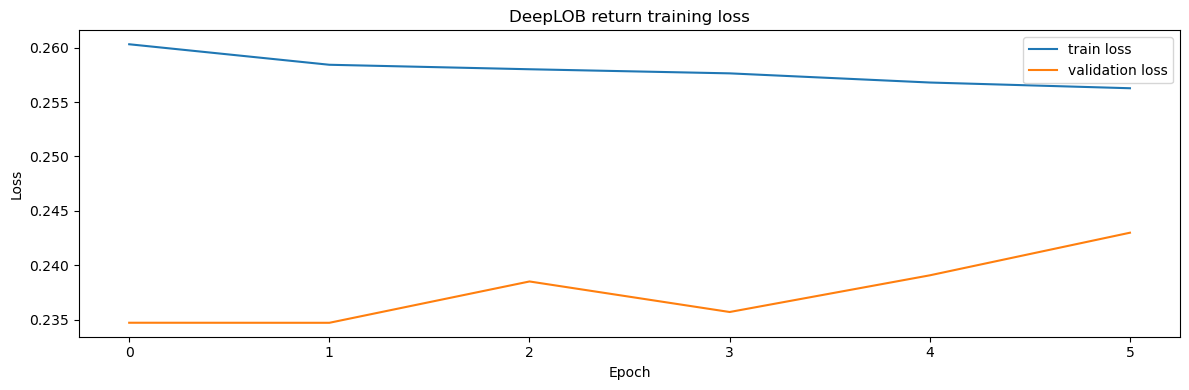

In [79]:
plot_loss_curves(train_losses, val_losses, title='DeepLOB return training loss')


# Prediction Check

We evaluate on the standardized test sequences, invert the target scaling back to return space, compare against the `last mid-price` baseline, and plot the return forecast directly.


In [80]:
load_best_checkpoint(model, checkpoint_path, device)

prediction_frame = make_prediction_frame(
    model=model,
    dataset=data_bundle.test_dataset,
    standardizer=data_bundle.standardizer,
    device=device,
    target_column=data_bundle.target_column,
)
metrics = evaluate_return_predictions(prediction_frame, target_column=data_bundle.target_column)

print(metrics)
print(prediction_frame[['timestamp_utc', 'target_return', 'smoothed_return', 'predicted_target_value', 'current_mid_price', 'target_mid_price', 'predicted_mid_price']].head())

   target_column  return_mae_bps  return_rmse_bps  \
0  target_return        1.610279         2.791448   

   persistence_return_rmse_bps  rmse_gain_vs_persistence_bps  return_ic  \
0                     2.828798                      0.037349   0.163038   

   direction_accuracy  
0             0.53574  
              timestamp_utc  target_return  smoothed_return  \
0 2023-01-18 14:12:23+00:00      -0.000809        -0.000427   
1 2023-01-18 14:12:24+00:00      -0.000604        -0.000283   
2 2023-01-18 14:12:25+00:00      -0.000521        -0.000242   
3 2023-01-18 14:12:26+00:00      -0.000525        -0.000294   
4 2023-01-18 14:12:27+00:00      -0.000669        -0.000361   

   predicted_target_value  current_mid_price  target_mid_price  \
0               -0.000100           21517.45          21500.05   
1               -0.000060           21513.05          21500.05   
2               -0.000072           21511.05          21499.85   
3                0.000044           21511.05       

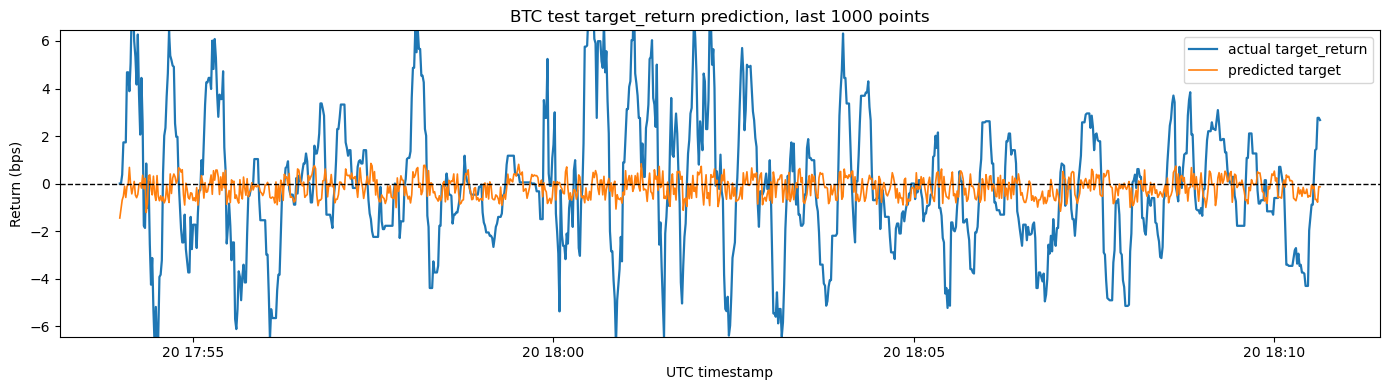

In [81]:
plot_return_predictions(prediction_frame, points=plot_points, target_column=data_bundle.target_column)

# Transformer Return Forecasting

Research note: TransLOB showed that attention can help limit order book prediction on FI-2010 style tensors, but the paper uses a heavier CNN plus transformer stack. For a first stable run here, we keep the same standardized `sequence_length x feature_dim` windows and use a smaller encoder-only transformer:

- linear projection from LOB features to `d_model`,
- learnable position embeddings across the 10-step window,
- a shallow `TransformerEncoder`,
- a tiny validation grid over width/dropout before the final run.

Because each sample already only contains observed history, this section uses full self-attention inside the window and still avoids target leakage.

In [82]:
class LOBTransformerRegressor(nn.Module):
    def __init__(
        self,
        feature_dim: int,
        sequence_length: int,
        model_dim: int = 64,
        num_heads: int = 4,
        num_layers: int = 2,
        ff_dim: int = 128,
        dropout_rate: float = 0.1,
        pooling: str = 'last',
    ):
        super().__init__()

        if model_dim % num_heads != 0:
            raise ValueError('model_dim must be divisible by num_heads.')
        if pooling not in {'last', 'mean'}:
            raise ValueError("pooling must be 'last' or 'mean'.")

        self.sequence_length = sequence_length
        self.pooling = pooling
        self.input_projection = nn.Linear(feature_dim, model_dim)
        self.position_embedding = nn.Parameter(torch.zeros(1, sequence_length, model_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout_rate,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(model_dim),
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.head = nn.Linear(model_dim, 1)

        self._reset_parameters()

    def _reset_parameters(self) -> None:
        nn.init.xavier_uniform_(self.input_projection.weight)
        nn.init.zeros_(self.input_projection.bias)
        nn.init.normal_(self.position_embedding, mean=0.0, std=0.02)
        nn.init.xavier_uniform_(self.head.weight)
        nn.init.zeros_(self.head.bias)

        for layer in self.encoder.layers:
            for module in layer.modules():
                if isinstance(module, nn.Linear):
                    nn.init.xavier_uniform_(module.weight)
                    if module.bias is not None:
                        nn.init.zeros_(module.bias)
                elif isinstance(module, nn.LayerNorm):
                    nn.init.ones_(module.weight)
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 4:
            x = x.squeeze(1)
        if x.dim() != 3:
            raise ValueError(f'Expected a 3D tensor, got shape={tuple(x.shape)}.')
        if x.size(1) != self.sequence_length:
            raise ValueError(f'Expected sequence length {self.sequence_length}, got {x.size(1)}.')

        x = self.input_projection(x)
        x = x + self.position_embedding[:, :x.size(1)]
        x = self.encoder(x)
        if self.pooling == 'last':
            x = x[:, -1, :]
        else:
            x = x.mean(dim=1)
        x = self.dropout(x)
        return self.head(x).squeeze(-1)


def run_transformer_grid_search(
    data_bundle: SequenceBundle,
    search_space: list[dict[str, float | int]],
    default_learning_rate: float,
    default_weight_decay: float,
    device: torch.device,
    search_epochs: int,
    early_stopping_patience: int,
    objective_name: str,
    directional_loss_weight: float,
    tail_weight: float,
    tail_quantile: float,
    use_scheduler: bool,
    scheduler_factor: float,
    scheduler_patience: int,
    scheduler_min_lr: float,
    max_gradient_norm: float | None,
) -> pd.DataFrame:
    rows = []
    temp_checkpoint_path = '_transformer_return_search_tmp.pt'

    for config in search_space:
        torch.manual_seed(42)
        np.random.seed(42)

        model = LOBTransformerRegressor(
            feature_dim=len(data_bundle.feature_columns),
            sequence_length=data_bundle.sequence_length,
            model_dim=int(config['model_dim']),
            num_heads=int(config['num_heads']),
            num_layers=int(config['num_layers']),
            ff_dim=int(config['ff_dim']),
            dropout_rate=float(config['dropout_rate']),
            pooling=str(config.get('pooling', 'last')),
        ).to(device)
        criterion = build_return_objective(
            objective_name=objective_name,
            directional_loss_weight=directional_loss_weight,
            tail_weight=tail_weight,
            tail_quantile=tail_quantile,
        )
        config_learning_rate = float(config.get('learning_rate', default_learning_rate))
        config_weight_decay = float(config.get('weight_decay', default_weight_decay))
        optimizer = torch.optim.AdamW(model.parameters(), lr=config_learning_rate, weight_decay=config_weight_decay)
        scheduler = build_plateau_scheduler(
            optimizer=optimizer,
            use_scheduler=use_scheduler,
            factor=scheduler_factor,
            patience=scheduler_patience,
            min_lr=scheduler_min_lr,
        )

        train_model(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            train_loader=data_bundle.train_loader,
            val_loader=data_bundle.val_loader,
            device=device,
            epochs=search_epochs,
            checkpoint_path=temp_checkpoint_path,
            early_stopping_patience=early_stopping_patience,
            scheduler=scheduler,
            max_gradient_norm=max_gradient_norm,
        )
        load_best_checkpoint(model, temp_checkpoint_path, device)
        val_prediction_frame = make_prediction_frame(
            model=model,
            dataset=data_bundle.val_dataset,
            standardizer=data_bundle.standardizer,
            device=device,
            target_column=data_bundle.target_column,
        )
        val_metrics = evaluate_return_predictions(val_prediction_frame, target_column=data_bundle.target_column).iloc[0].to_dict()
        row = {
            'model_dim': int(config['model_dim']),
            'num_heads': int(config['num_heads']),
            'num_layers': int(config['num_layers']),
            'ff_dim': int(config['ff_dim']),
            'dropout_rate': float(config['dropout_rate']),
            'pooling': str(config.get('pooling', 'last')),
            'learning_rate': config_learning_rate,
            'weight_decay': config_weight_decay,
            **{f'val_{metric_name}': metric_value for metric_name, metric_value in val_metrics.items()},
        }
        rows.append(row)

        del model, criterion, optimizer, scheduler, val_prediction_frame, val_metrics
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if os.path.exists(temp_checkpoint_path):
        os.remove(temp_checkpoint_path)

    results = pd.DataFrame(rows)
    return results.sort_values(
        ['val_return_rmse_bps', 'val_return_mae_bps', 'val_return_ic'],
        ascending=[True, True, False],
    ).reset_index(drop=True)

In [83]:
transformer_checkpoint_path = 'best_val_model_pytorch_btc20230120_transformer_return_10s.pt'
transformer_search_epochs = min(3, epochs)
transformer_search_space = [
    {'model_dim': 64, 'num_heads': 4, 'num_layers': 2, 'ff_dim': 128, 'dropout_rate': 0.10, 'pooling': 'last', 'learning_rate': 5e-5, 'weight_decay': 1e-4},
    {'model_dim': 96, 'num_heads': 4, 'num_layers': 2, 'ff_dim': 192, 'dropout_rate': 0.10, 'pooling': 'last', 'learning_rate': 5e-5, 'weight_decay': 1e-4},
    {'model_dim': 96, 'num_heads': 4, 'num_layers': 2, 'ff_dim': 192, 'dropout_rate': 0.20, 'pooling': 'mean', 'learning_rate': 5e-5, 'weight_decay': 1e-4},
    {'model_dim': 128, 'num_heads': 8, 'num_layers': 2, 'ff_dim': 256, 'dropout_rate': 0.10, 'pooling': 'mean', 'learning_rate': 1e-4, 'weight_decay': 5e-4},
]

transformer_search_results = run_transformer_grid_search(
    data_bundle=data_bundle,
    search_space=transformer_search_space,
    default_learning_rate=learning_rate,
    default_weight_decay=weight_decay,
    device=device,
    search_epochs=transformer_search_epochs,
    early_stopping_patience=min(2, early_stopping_patience),
    objective_name=return_objective_name,
    directional_loss_weight=directional_loss_weight,
    tail_weight=tail_weight,
    tail_quantile=tail_weight_quantile,
    use_scheduler=use_plateau_scheduler,
    scheduler_factor=plateau_factor,
    scheduler_patience=plateau_patience,
    scheduler_min_lr=plateau_min_lr,
    max_gradient_norm=max_gradient_norm,
)

print('transformer validation search')
print(
    transformer_search_results[
        [
            'model_dim',
            'num_heads',
            'num_layers',
            'ff_dim',
            'dropout_rate',
            'pooling',
            'learning_rate',
            'weight_decay',
            'val_target_column',
            'val_return_rmse_bps',
            'val_return_mae_bps',
            'val_return_ic',
            'val_direction_accuracy',
        ]
    ].to_string(index=False)
)

selected_transformer_row = transformer_search_results.iloc[0]
selected_transformer_model_config = {
    'model_dim': int(selected_transformer_row['model_dim']),
    'num_heads': int(selected_transformer_row['num_heads']),
    'num_layers': int(selected_transformer_row['num_layers']),
    'ff_dim': int(selected_transformer_row['ff_dim']),
    'dropout_rate': float(selected_transformer_row['dropout_rate']),
    'pooling': str(selected_transformer_row['pooling']),
}
selected_transformer_optim_config = {
    'learning_rate': float(selected_transformer_row['learning_rate']),
    'weight_decay': float(selected_transformer_row['weight_decay']),
}
print(f'selected transformer model config={selected_transformer_model_config}')
print(f'selected transformer optimizer config={selected_transformer_optim_config}')

transformer_model = LOBTransformerRegressor(
    feature_dim=len(data_bundle.feature_columns),
    sequence_length=data_bundle.sequence_length,
    **selected_transformer_model_config,
).to(device)
summary(transformer_model, (1, 1, data_bundle.sequence_length, len(data_bundle.feature_columns)))

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

transformer validation search
 model_dim  num_heads  num_layers  ff_dim  dropout_rate pooling  learning_rate  weight_decay val_target_column  val_return_rmse_bps  val_return_mae_bps  val_return_ic  val_direction_accuracy
        64          4           2     128           0.1    last        0.00005        0.0001     target_return             2.834858            1.718870       0.159838                0.554206
        96          4           2     192           0.1    last        0.00005        0.0001     target_return             2.835783            1.720616       0.157784                0.552853
       128          8           2     256           0.1    mean        0.00010        0.0005     target_return             2.855502            1.735694       0.124174                0.546201
        96          4           2     192           0.2    mean        0.00005        0.0001     target_return             2.870605            1.752076       0.046081                0.497762
selected transf

Layer (type:depth-idx)                        Output Shape              Param #
LOBTransformerRegressor                       [1]                       640
├─Linear: 1-1                                 [1, 10, 64]               3,072
├─TransformerEncoder: 1-2                     [1, 10, 64]               --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 10, 64]               33,472
│    │    └─TransformerEncoderLayer: 3-2      [1, 10, 64]               33,472
│    └─LayerNorm: 2-2                         [1, 10, 64]               128
├─Dropout: 1-3                                [1, 64]                   --
├─Linear: 1-4                                 [1, 1]                    65
Total params: 70,849
Trainable params: 70,849
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.04
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.15
Estimated Total Size (MB): 0.21

In [84]:
transformer_criterion = build_return_objective(
    objective_name=return_objective_name,
    directional_loss_weight=directional_loss_weight,
    tail_weight=tail_weight,
    tail_quantile=tail_weight_quantile,
)
transformer_optimizer = torch.optim.AdamW(
    transformer_model.parameters(),
    lr=selected_transformer_optim_config['learning_rate'],
    weight_decay=selected_transformer_optim_config['weight_decay'],
)
transformer_scheduler = build_plateau_scheduler(
    optimizer=transformer_optimizer,
    use_scheduler=use_plateau_scheduler,
    factor=plateau_factor,
    patience=plateau_patience,
    min_lr=plateau_min_lr,
)

transformer_train_losses, transformer_val_losses = train_model(
    model=transformer_model,
    criterion=transformer_criterion,
    optimizer=transformer_optimizer,
    train_loader=data_bundle.train_loader,
    val_loader=data_bundle.val_loader,
    device=device,
    epochs=epochs,
    checkpoint_path=transformer_checkpoint_path,
    early_stopping_patience=early_stopping_patience,
    scheduler=transformer_scheduler,
    max_gradient_norm=max_gradient_norm,
)

  0%|          | 0/20 [00:00<?, ?it/s]

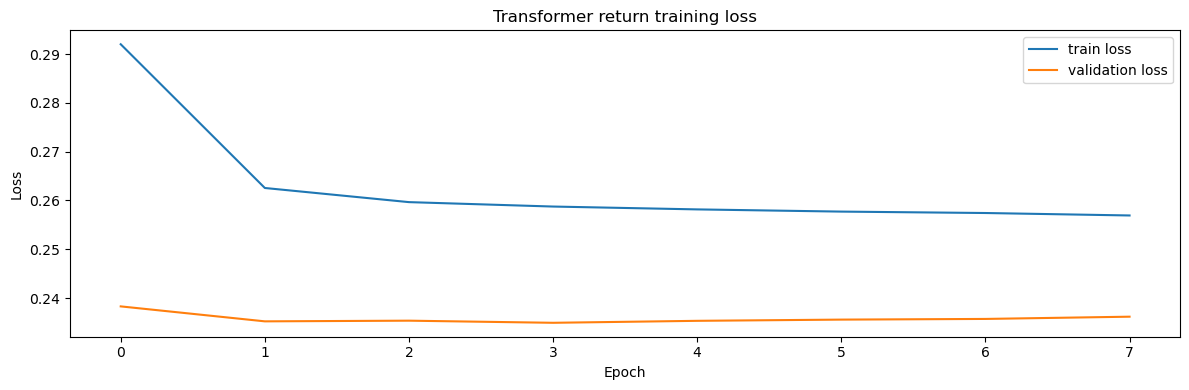

In [85]:
plot_loss_curves(transformer_train_losses, transformer_val_losses, title='Transformer return training loss')

In [86]:
load_best_checkpoint(transformer_model, transformer_checkpoint_path, device)

transformer_prediction_frame = make_prediction_frame(
    model=transformer_model,
    dataset=data_bundle.test_dataset,
    standardizer=data_bundle.standardizer,
    device=device,
    target_column=data_bundle.target_column,
)
transformer_metrics = evaluate_return_predictions(transformer_prediction_frame, target_column=data_bundle.target_column)

print('transformer test metrics')
print(transformer_metrics)
print(transformer_prediction_frame[['timestamp_utc', 'target_return', 'smoothed_return', 'predicted_target_value', 'current_mid_price', 'target_mid_price', 'predicted_mid_price']].head())

transformer test metrics
   target_column  return_mae_bps  return_rmse_bps  \
0  target_return         1.62008         2.803324   

   persistence_return_rmse_bps  rmse_gain_vs_persistence_bps  return_ic  \
0                     2.828798                      0.025474   0.140686   

   direction_accuracy  
0            0.539676  
              timestamp_utc  target_return  smoothed_return  \
0 2023-01-18 14:12:23+00:00      -0.000809        -0.000427   
1 2023-01-18 14:12:24+00:00      -0.000604        -0.000283   
2 2023-01-18 14:12:25+00:00      -0.000521        -0.000242   
3 2023-01-18 14:12:26+00:00      -0.000525        -0.000294   
4 2023-01-18 14:12:27+00:00      -0.000669        -0.000361   

   predicted_target_value  current_mid_price  target_mid_price  \
0               -0.000060           21517.45          21500.05   
1               -0.000048           21513.05          21500.05   
2               -0.000024           21511.05          21499.85   
3                0.000052 

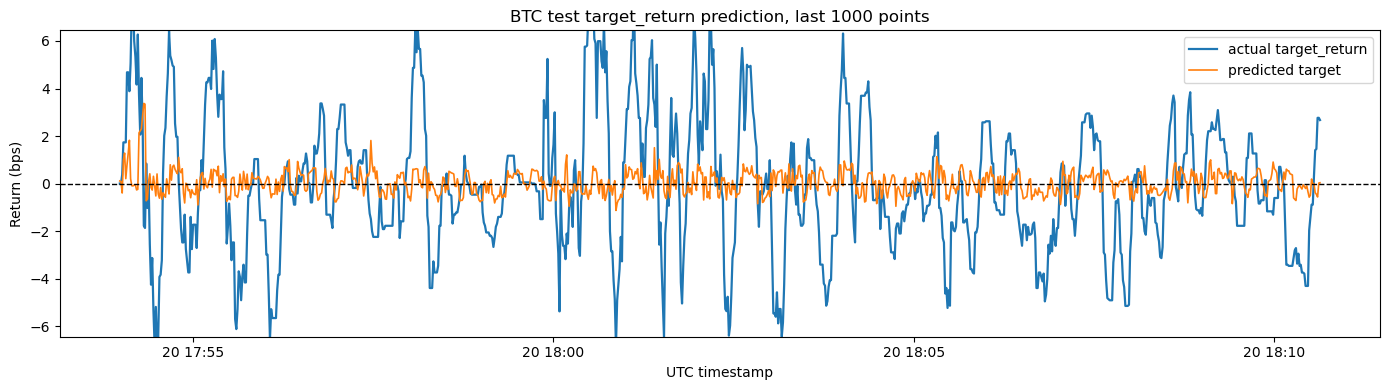

In [87]:
plot_return_predictions(transformer_prediction_frame, points=plot_points, target_column=data_bundle.target_column)

# Conv-Transformer Return Forecasting

Research note: a common failure mode for a pure transformer on LOB data is that it sees the time axis,
but not the local price-level structure as effectively as DeepLOB-style convolutions. This hybrid keeps
the DeepLOB convolutional stem for local book patterns, then replaces the temporal LSTM tail with a
transformer encoder over the sequence.

In [88]:
class DeepLOBConvStem(nn.Module):
    def __init__(self, feature_dim: int):
        super().__init__()

        width_after_conv1 = ((feature_dim - 2) // 2) + 1
        width_after_conv2 = ((width_after_conv1 - 2) // 2) + 1
        if width_after_conv2 < 1:
            raise ValueError(f'feature_dim={feature_dim} is too small for the DeepLOB backbone.')

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(1, 2), stride=(1, 2)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1, 2), stride=(1, 2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4, 1), padding='same'),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4, 1), padding='same'),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1, width_after_conv2)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.inp1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(5, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.output_dim = 192

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x_inp1 = self.inp1(x)
        x_inp2 = self.inp2(x)
        x_inp3 = self.inp3(x)
        x = torch.cat((x_inp1, x_inp2, x_inp3), dim=1)
        x = x.permute(0, 2, 1, 3)
        return torch.reshape(x, (-1, x.shape[1], x.shape[2]))


class HybridLOBTransformerRegressor(nn.Module):
    def __init__(
        self,
        feature_dim: int,
        sequence_length: int,
        model_dim: int = 96,
        num_heads: int = 4,
        num_layers: int = 2,
        ff_dim: int = 192,
        dropout_rate: float = 0.1,
        pooling: str = 'last',
    ):
        super().__init__()
        if model_dim % num_heads != 0:
            raise ValueError('model_dim must be divisible by num_heads.')
        if pooling not in {'last', 'mean'}:
            raise ValueError("pooling must be 'last' or 'mean'.")

        self.sequence_length = sequence_length
        self.pooling = pooling
        self.stem = DeepLOBConvStem(feature_dim=feature_dim)
        self.temporal_projection = nn.Linear(self.stem.output_dim, model_dim)
        self.position_embedding = nn.Parameter(torch.zeros(1, sequence_length, model_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout_rate,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(model_dim),
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.head = nn.Linear(model_dim, 1)
        self._reset_parameters()

    def _reset_parameters(self) -> None:
        nn.init.xavier_uniform_(self.temporal_projection.weight)
        nn.init.zeros_(self.temporal_projection.bias)
        nn.init.normal_(self.position_embedding, mean=0.0, std=0.02)
        nn.init.xavier_uniform_(self.head.weight)
        nn.init.zeros_(self.head.bias)
        for layer in self.encoder.layers:
            for module in layer.modules():
                if isinstance(module, nn.Linear):
                    nn.init.xavier_uniform_(module.weight)
                    if module.bias is not None:
                        nn.init.zeros_(module.bias)
                elif isinstance(module, nn.LayerNorm):
                    nn.init.ones_(module.weight)
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.size(2) != self.sequence_length:
            raise ValueError(f'Expected sequence length {self.sequence_length}, got {x.size(2)}.')
        x = self.stem(x)
        x = self.temporal_projection(x)
        x = x + self.position_embedding[:, :x.size(1)]
        x = self.encoder(x)
        if self.pooling == 'last':
            x = x[:, -1, :]
        else:
            x = x.mean(dim=1)
        x = self.dropout(x)
        return self.head(x).squeeze(-1)


def run_hybrid_transformer_grid_search(
    data_bundle: SequenceBundle,
    search_space: list[dict[str, float | int | str]],
    default_learning_rate: float,
    default_weight_decay: float,
    device: torch.device,
    search_epochs: int,
    early_stopping_patience: int,
    objective_name: str,
    directional_loss_weight: float,
    tail_weight: float,
    tail_quantile: float,
    use_scheduler: bool,
    scheduler_factor: float,
    scheduler_patience: int,
    scheduler_min_lr: float,
    max_gradient_norm: float | None,
) -> pd.DataFrame:
    rows = []
    temp_checkpoint_path = '_hybrid_return_search_tmp.pt'

    for config in search_space:
        torch.manual_seed(42)
        np.random.seed(42)

        model = HybridLOBTransformerRegressor(
            feature_dim=len(data_bundle.feature_columns),
            sequence_length=data_bundle.sequence_length,
            model_dim=int(config['model_dim']),
            num_heads=int(config['num_heads']),
            num_layers=int(config['num_layers']),
            ff_dim=int(config['ff_dim']),
            dropout_rate=float(config['dropout_rate']),
            pooling=str(config.get('pooling', 'last')),
        ).to(device)
        criterion = build_return_objective(
            objective_name=objective_name,
            directional_loss_weight=directional_loss_weight,
            tail_weight=tail_weight,
            tail_quantile=tail_quantile,
        )
        config_learning_rate = float(config.get('learning_rate', default_learning_rate))
        config_weight_decay = float(config.get('weight_decay', default_weight_decay))
        optimizer = torch.optim.AdamW(model.parameters(), lr=config_learning_rate, weight_decay=config_weight_decay)
        scheduler = build_plateau_scheduler(
            optimizer=optimizer,
            use_scheduler=use_scheduler,
            factor=scheduler_factor,
            patience=scheduler_patience,
            min_lr=scheduler_min_lr,
        )

        train_model(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            train_loader=data_bundle.train_loader,
            val_loader=data_bundle.val_loader,
            device=device,
            epochs=search_epochs,
            checkpoint_path=temp_checkpoint_path,
            early_stopping_patience=early_stopping_patience,
            scheduler=scheduler,
            max_gradient_norm=max_gradient_norm,
        )
        load_best_checkpoint(model, temp_checkpoint_path, device)
        val_prediction_frame = make_prediction_frame(
            model=model,
            dataset=data_bundle.val_dataset,
            standardizer=data_bundle.standardizer,
            device=device,
            target_column=data_bundle.target_column,
        )
        val_metrics = evaluate_return_predictions(val_prediction_frame, target_column=data_bundle.target_column).iloc[0].to_dict()
        row = {
            'model_dim': int(config['model_dim']),
            'num_heads': int(config['num_heads']),
            'num_layers': int(config['num_layers']),
            'ff_dim': int(config['ff_dim']),
            'dropout_rate': float(config['dropout_rate']),
            'pooling': str(config.get('pooling', 'last')),
            'learning_rate': config_learning_rate,
            'weight_decay': config_weight_decay,
            **{f'val_{metric_name}': metric_value for metric_name, metric_value in val_metrics.items()},
        }
        rows.append(row)

        del model, criterion, optimizer, scheduler, val_prediction_frame, val_metrics
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if os.path.exists(temp_checkpoint_path):
        os.remove(temp_checkpoint_path)

    results = pd.DataFrame(rows)
    return results.sort_values(
        ['val_return_rmse_bps', 'val_return_mae_bps', 'val_return_ic'],
        ascending=[True, True, False],
    ).reset_index(drop=True)

In [89]:
hybrid_checkpoint_path = 'best_val_model_pytorch_btc20230120_hybrid_transformer_return_10s.pt'
hybrid_search_epochs = min(3, epochs)
hybrid_search_space = [
    {'model_dim': 96, 'num_heads': 4, 'num_layers': 2, 'ff_dim': 192, 'dropout_rate': 0.10, 'pooling': 'last', 'learning_rate': 5e-5, 'weight_decay': 1e-4},
    {'model_dim': 96, 'num_heads': 4, 'num_layers': 2, 'ff_dim': 192, 'dropout_rate': 0.20, 'pooling': 'mean', 'learning_rate': 5e-5, 'weight_decay': 1e-4},
    {'model_dim': 128, 'num_heads': 8, 'num_layers': 2, 'ff_dim': 256, 'dropout_rate': 0.10, 'pooling': 'mean', 'learning_rate': 1e-4, 'weight_decay': 5e-4},
]

hybrid_search_results = run_hybrid_transformer_grid_search(
    data_bundle=data_bundle,
    search_space=hybrid_search_space,
    default_learning_rate=learning_rate,
    default_weight_decay=weight_decay,
    device=device,
    search_epochs=hybrid_search_epochs,
    early_stopping_patience=min(2, early_stopping_patience),
    objective_name=return_objective_name,
    directional_loss_weight=directional_loss_weight,
    tail_weight=tail_weight,
    tail_quantile=tail_weight_quantile,
    use_scheduler=use_plateau_scheduler,
    scheduler_factor=plateau_factor,
    scheduler_patience=plateau_patience,
    scheduler_min_lr=plateau_min_lr,
    max_gradient_norm=max_gradient_norm,
)

print('hybrid validation search')
print(
    hybrid_search_results[
        [
            'model_dim',
            'num_heads',
            'num_layers',
            'ff_dim',
            'dropout_rate',
            'pooling',
            'learning_rate',
            'weight_decay',
            'val_target_column',
            'val_return_rmse_bps',
            'val_return_mae_bps',
            'val_return_ic',
            'val_direction_accuracy',
        ]
    ].to_string(index=False)
)

selected_hybrid_row = hybrid_search_results.iloc[0]
selected_hybrid_model_config = {
    'model_dim': int(selected_hybrid_row['model_dim']),
    'num_heads': int(selected_hybrid_row['num_heads']),
    'num_layers': int(selected_hybrid_row['num_layers']),
    'ff_dim': int(selected_hybrid_row['ff_dim']),
    'dropout_rate': float(selected_hybrid_row['dropout_rate']),
    'pooling': str(selected_hybrid_row['pooling']),
}
selected_hybrid_optim_config = {
    'learning_rate': float(selected_hybrid_row['learning_rate']),
    'weight_decay': float(selected_hybrid_row['weight_decay']),
}
print(f'selected hybrid model config={selected_hybrid_model_config}')
print(f'selected hybrid optimizer config={selected_hybrid_optim_config}')

hybrid_model = HybridLOBTransformerRegressor(
    feature_dim=len(data_bundle.feature_columns),
    sequence_length=data_bundle.sequence_length,
    **selected_hybrid_model_config,
).to(device)
summary(hybrid_model, (1, 1, data_bundle.sequence_length, len(data_bundle.feature_columns)))

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

hybrid validation search
 model_dim  num_heads  num_layers  ff_dim  dropout_rate pooling  learning_rate  weight_decay val_target_column  val_return_rmse_bps  val_return_mae_bps  val_return_ic  val_direction_accuracy
        96          4           2     192           0.1    last        0.00005        0.0001     target_return             2.832570            1.719018       0.164011                0.554505
       128          8           2     256           0.1    mean        0.00010        0.0005     target_return             2.832905            1.720593       0.166492                0.551409
        96          4           2     192           0.2    mean        0.00005        0.0001     target_return             2.833223            1.724483       0.165627                0.554061
selected hybrid model config={'model_dim': 96, 'num_heads': 4, 'num_layers': 2, 'ff_dim': 192, 'dropout_rate': 0.1, 'pooling': 'last'}
selected hybrid optimizer config={'learning_rate': 5e-05, 'weight_decay': 0.

Layer (type:depth-idx)                        Output Shape              Param #
HybridLOBTransformerRegressor                 [1]                       960
├─DeepLOBConvStem: 1-1                        [1, 10, 192]              --
│    └─Sequential: 2-1                        [1, 32, 10, 23]           --
│    │    └─Conv2d: 3-1                       [1, 32, 10, 23]           96
│    │    └─LeakyReLU: 3-2                    [1, 32, 10, 23]           --
│    │    └─BatchNorm2d: 3-3                  [1, 32, 10, 23]           64
│    │    └─Conv2d: 3-4                       [1, 32, 10, 23]           4,128
│    │    └─LeakyReLU: 3-5                    [1, 32, 10, 23]           --
│    │    └─BatchNorm2d: 3-6                  [1, 32, 10, 23]           64
│    │    └─Conv2d: 3-7                       [1, 32, 10, 23]           4,128
│    │    └─LeakyReLU: 3-8                    [1, 32, 10, 23]           --
│    │    └─BatchNorm2d: 3-9                  [1, 32, 10, 23]           64
│    └─Sequen

In [90]:
hybrid_criterion = build_return_objective(
    objective_name=return_objective_name,
    directional_loss_weight=directional_loss_weight,
    tail_weight=tail_weight,
    tail_quantile=tail_weight_quantile,
)
hybrid_optimizer = torch.optim.AdamW(
    hybrid_model.parameters(),
    lr=selected_hybrid_optim_config['learning_rate'],
    weight_decay=selected_hybrid_optim_config['weight_decay'],
)
hybrid_scheduler = build_plateau_scheduler(
    optimizer=hybrid_optimizer,
    use_scheduler=use_plateau_scheduler,
    factor=plateau_factor,
    patience=plateau_patience,
    min_lr=plateau_min_lr,
)

hybrid_train_losses, hybrid_val_losses = train_model(
    model=hybrid_model,
    criterion=hybrid_criterion,
    optimizer=hybrid_optimizer,
    train_loader=data_bundle.train_loader,
    val_loader=data_bundle.val_loader,
    device=device,
    epochs=epochs,
    checkpoint_path=hybrid_checkpoint_path,
    early_stopping_patience=early_stopping_patience,
    scheduler=hybrid_scheduler,
    max_gradient_norm=max_gradient_norm,
)

  0%|          | 0/20 [00:00<?, ?it/s]

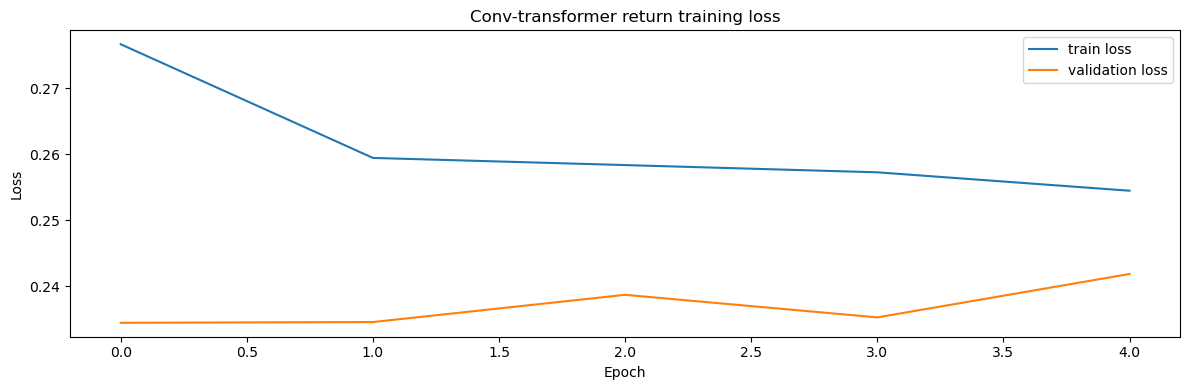

In [91]:
plot_loss_curves(hybrid_train_losses, hybrid_val_losses, title='Conv-transformer return training loss')

In [92]:
load_best_checkpoint(hybrid_model, hybrid_checkpoint_path, device)

hybrid_prediction_frame = make_prediction_frame(
    model=hybrid_model,
    dataset=data_bundle.test_dataset,
    standardizer=data_bundle.standardizer,
    device=device,
    target_column=data_bundle.target_column,
)
hybrid_metrics = evaluate_return_predictions(hybrid_prediction_frame, target_column=data_bundle.target_column)

print('hybrid transformer test metrics')
print(hybrid_metrics)
print(hybrid_prediction_frame[['timestamp_utc', 'target_return', 'smoothed_return', 'predicted_target_value', 'current_mid_price', 'target_mid_price', 'predicted_mid_price']].head())

hybrid transformer test metrics
   target_column  return_mae_bps  return_rmse_bps  \
0  target_return        1.612281         2.790846   

   persistence_return_rmse_bps  rmse_gain_vs_persistence_bps  return_ic  \
0                     2.828798                      0.037951   0.165116   

   direction_accuracy  
0            0.537585  
              timestamp_utc  target_return  smoothed_return  \
0 2023-01-18 14:12:23+00:00      -0.000809        -0.000427   
1 2023-01-18 14:12:24+00:00      -0.000604        -0.000283   
2 2023-01-18 14:12:25+00:00      -0.000521        -0.000242   
3 2023-01-18 14:12:26+00:00      -0.000525        -0.000294   
4 2023-01-18 14:12:27+00:00      -0.000669        -0.000361   

   predicted_target_value  current_mid_price  target_mid_price  \
0               -0.000078           21517.45          21500.05   
1               -0.000049           21513.05          21500.05   
2               -0.000041           21511.05          21499.85   
3                0.

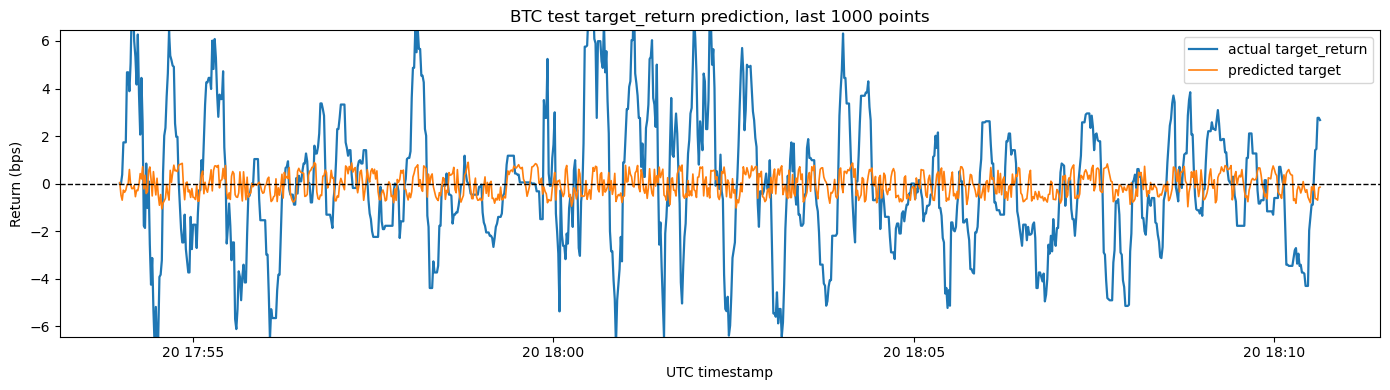

In [93]:
plot_return_predictions(hybrid_prediction_frame, points=plot_points, target_column=data_bundle.target_column)

# Naive Direction Prediction

The naive version only changes the target from return to direction. The features, time split, and standardization stay the same.


In [94]:
naive_direction_checkpoint_path = 'best_val_model_pytorch_btc20230120_direction_naive_10s.pt'

naive_direction_bundle = build_direction_bundle(
    data_bundle=data_bundle,
    label_mode='naive',
    batch_size=batch_size,
)
naive_flat_baseline_frame = make_always_flat_prediction_frame(naive_direction_bundle['test_dataset'])
naive_flat_metrics, naive_flat_confusion = compute_direction_metrics(naive_flat_baseline_frame)

print('naive train class distribution')
print(naive_direction_bundle['class_distribution'])
print('always-flat baseline metrics')
print(naive_flat_metrics)
print(naive_flat_confusion)
            


naive train class distribution
-1    0.393264
 0    0.211058
 1    0.395679
Name: proportion, dtype: float64
always-flat baseline metrics
   accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1  \
0  0.156024           0.333333         0.052008      0.333333  0.089977   

   non_flat_precision  non_flat_recall  predicted_non_flat_share  \
0                 NaN              0.0                       0.0   

   actual_non_flat_share  
0               0.843976  
      down   flat  up
down     0  80709   0
flat     0  29181   0
up       0  77139   0


  0%|          | 0/20 [00:00<?, ?it/s]

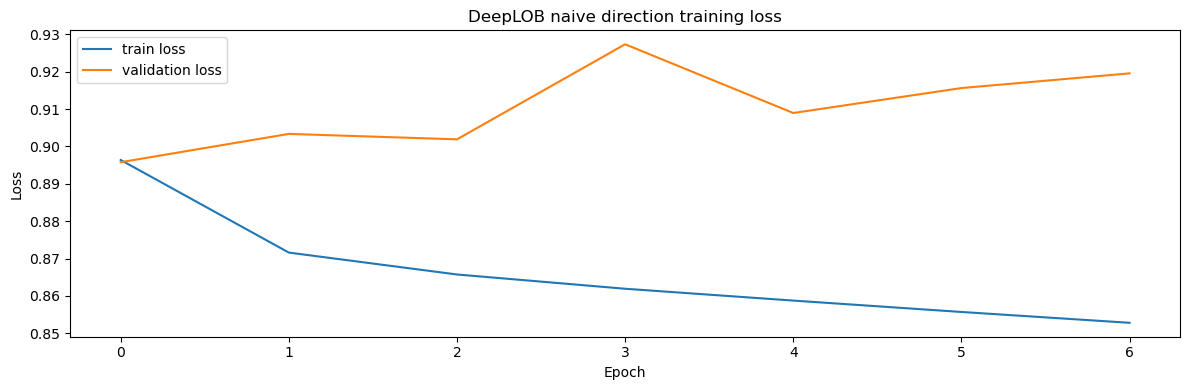

In [95]:
naive_direction_model = DeepLOBClassifier(
    feature_dim=len(data_bundle.feature_columns),
    hidden_size=model_hidden_size,
    dropout_rate=model_dropout,
).to(device)
naive_direction_criterion = nn.CrossEntropyLoss()
naive_direction_optimizer = torch.optim.AdamW(naive_direction_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

naive_direction_train_losses, naive_direction_val_losses = train_classification_model(
    model=naive_direction_model,
    criterion=naive_direction_criterion,
    optimizer=naive_direction_optimizer,
    train_loader=naive_direction_bundle['train_loader'],
    val_loader=naive_direction_bundle['val_loader'],
    device=device,
    epochs=epochs,
    checkpoint_path=naive_direction_checkpoint_path,
    early_stopping_patience=early_stopping_patience,
)
plot_loss_curves(naive_direction_train_losses, naive_direction_val_losses, title='DeepLOB naive direction training loss')
            


naive direction metrics
   accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1  \
0  0.550027           0.479533         0.524098      0.479533  0.486062   

   non_flat_precision  non_flat_recall  predicted_non_flat_share  \
0            0.557307         0.612216                  0.927129   

   actual_non_flat_share  
0               0.843976  
       down  flat     up
down  48475  3723  28511
flat  11699  6234  11248
up    25305  3672  48162
              timestamp_utc  target_direction  predicted_direction  prob_down  \
0 2023-01-18 14:12:23+00:00                -1                   -1   0.615260   
1 2023-01-18 14:12:24+00:00                -1                   -1   0.547080   
2 2023-01-18 14:12:25+00:00                -1                   -1   0.555015   
3 2023-01-18 14:12:26+00:00                -1                    1   0.489658   
4 2023-01-18 14:12:27+00:00                -1                   -1   0.513110   

   prob_flat   prob_up  
0   0.020434  0.364306

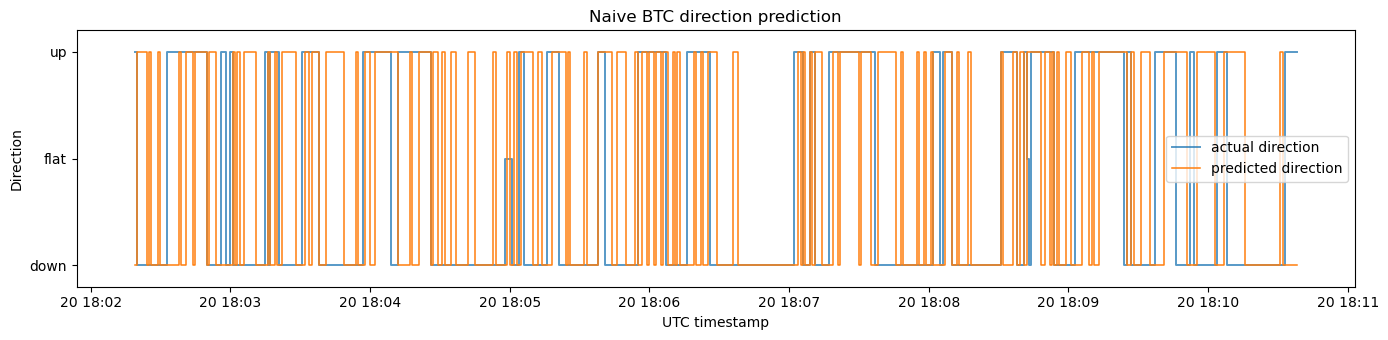

In [96]:
load_best_checkpoint(naive_direction_model, naive_direction_checkpoint_path, device)
naive_direction_prediction_frame = make_direction_prediction_frame(
    model=naive_direction_model,
    dataset=naive_direction_bundle['test_dataset'],
    device=device,
)
naive_direction_metrics, naive_direction_confusion = compute_direction_metrics(naive_direction_prediction_frame)

print('naive direction metrics')
print(naive_direction_metrics)
print(naive_direction_confusion)
print(naive_direction_prediction_frame[['timestamp_utc', 'target_direction', 'predicted_direction', 'prob_down', 'prob_flat', 'prob_up']].head())
plot_direction_predictions(naive_direction_prediction_frame, title='Naive BTC direction prediction', points=min(500, plot_points))
            


# Improved Direction Prediction

This version still keeps the model simple. The only extra step is a small threshold search,
so we can stop the classifier from calling too many `up/down` moves:

- use a smoothed future average price for labels,
- keep a small threshold around zero,
- search a few threshold sizes on validation,
- keep weighted loss and natural sampling.


In [97]:
improved_direction_checkpoint_path = 'best_val_model_pytorch_btc20230120_direction_improved_10s.pt'
# Keep the search small. We only tune the label threshold before the final improved run.
threshold_grid = [0.50, 0.75, 1.00, 1.25]
search_epochs = min(4, epochs)

threshold_search_results = run_direction_threshold_search(
    data_bundle=data_bundle,
    threshold_multipliers=threshold_grid,
    batch_size=batch_size,
    hidden_size=model_hidden_size,
    dropout_rate=model_dropout,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    device=device,
    search_epochs=search_epochs,
    early_stopping_patience=early_stopping_patience,
)

print('validation threshold search')
print(
    threshold_search_results[
        [
            'threshold_multiplier',
            'threshold_bps',
            'macro_f1',
            'balanced_accuracy',
            'non_flat_precision',
            'non_flat_recall',
            'predicted_non_flat_share',
            'actual_non_flat_share',
            'share_gap',
        ]
    ].to_string(index=False)
)

improved_direction_threshold_multiplier = float(threshold_search_results.loc[0, 'threshold_multiplier'])
improved_direction_bundle = build_direction_bundle(
    data_bundle=data_bundle,
    label_mode='improved',
    batch_size=batch_size,
    threshold_multiplier=improved_direction_threshold_multiplier,
)
improved_flat_baseline_frame = make_always_flat_prediction_frame(improved_direction_bundle['test_dataset'])
improved_flat_metrics, improved_flat_confusion = compute_direction_metrics(improved_flat_baseline_frame)

print(f"selected threshold multiplier={improved_direction_threshold_multiplier:.2f}")
print(f"improved threshold={improved_direction_bundle['threshold']:.8f}")
print('improved train class distribution')
print(improved_direction_bundle['class_distribution'])
print('class weights')
print(pd.Series(improved_direction_bundle['class_weights'], index=DIRECTION_NAMES))
print('always-flat baseline metrics')
print(improved_flat_metrics)
print(improved_flat_confusion)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

validation threshold search
 threshold_multiplier  threshold_bps  macro_f1  balanced_accuracy  non_flat_precision  non_flat_recall  predicted_non_flat_share  actual_non_flat_share  share_gap
                 1.00       0.053085  0.427962           0.442871            0.565760         0.640391                  0.980088               0.865869   0.114218
                 1.25       0.066356  0.420381           0.441017            0.559849         0.643985                  0.984820               0.856154   0.128666
                 0.50       0.026543  0.420302           0.437553            0.579301         0.645738                  0.992290               0.890198   0.102091
                 0.75       0.039814  0.416464           0.437190            0.571321         0.646026                  0.992065               0.877344   0.114721
selected threshold multiplier=1.00
improved threshold=0.00000531
improved train class distribution
-1    0.375491
 0    0.244077
 1    0.380432
Name: proport

  0%|          | 0/20 [00:00<?, ?it/s]

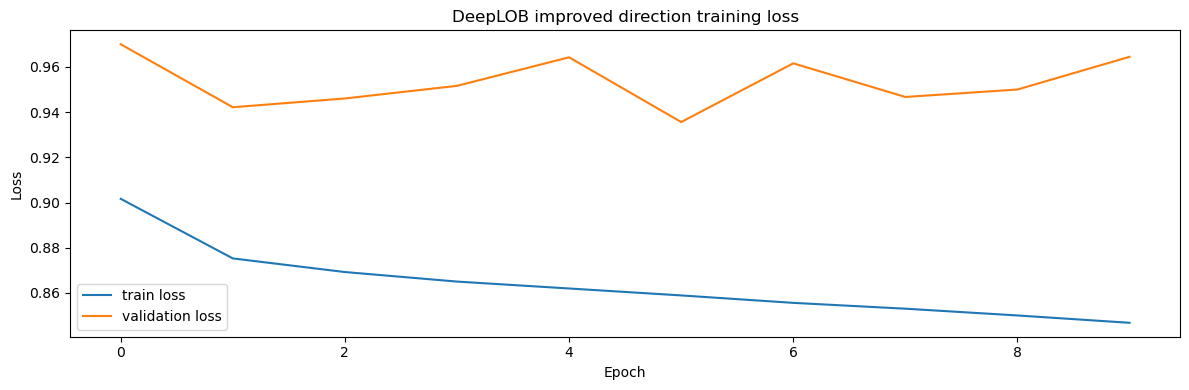

In [98]:
improved_direction_model = DeepLOBClassifier(
    feature_dim=len(data_bundle.feature_columns),
    hidden_size=model_hidden_size,
    dropout_rate=model_dropout,
).to(device)

# Trick: weighted cross-entropy makes missing up/down moves more expensive.
improved_class_weights = torch.tensor(improved_direction_bundle['class_weights'], dtype=torch.float32, device=device)
improved_direction_criterion = nn.CrossEntropyLoss(weight=improved_class_weights)
improved_direction_optimizer = torch.optim.AdamW(improved_direction_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

improved_direction_train_losses, improved_direction_val_losses = train_classification_model(
    model=improved_direction_model,
    criterion=improved_direction_criterion,
    optimizer=improved_direction_optimizer,
    train_loader=improved_direction_bundle['train_loader'],
    val_loader=improved_direction_bundle['val_loader'],
    device=device,
    epochs=epochs,
    checkpoint_path=improved_direction_checkpoint_path,
    early_stopping_patience=early_stopping_patience,
)
plot_loss_curves(improved_direction_train_losses, improved_direction_val_losses, title='DeepLOB improved direction training loss')
            


improved direction metrics
   accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1  \
0  0.553481           0.507444         0.531833      0.507444  0.512183   

   non_flat_precision  non_flat_recall  predicted_non_flat_share  \
0             0.56568         0.616395                  0.879634   

   actual_non_flat_share  
0                0.80726  
       down   flat     up
down  48275   6054  22615
flat  13389  10453  12206
up    23243   6005  44789
              timestamp_utc  target_direction  predicted_direction  prob_down  \
0 2023-01-18 14:12:23+00:00                -1                   -1   0.647097   
1 2023-01-18 14:12:24+00:00                -1                   -1   0.537576   
2 2023-01-18 14:12:25+00:00                -1                   -1   0.554260   
3 2023-01-18 14:12:26+00:00                -1                    1   0.379984   
4 2023-01-18 14:12:27+00:00                -1                    1   0.411601   

   prob_flat   prob_up  
0   0.063730  0

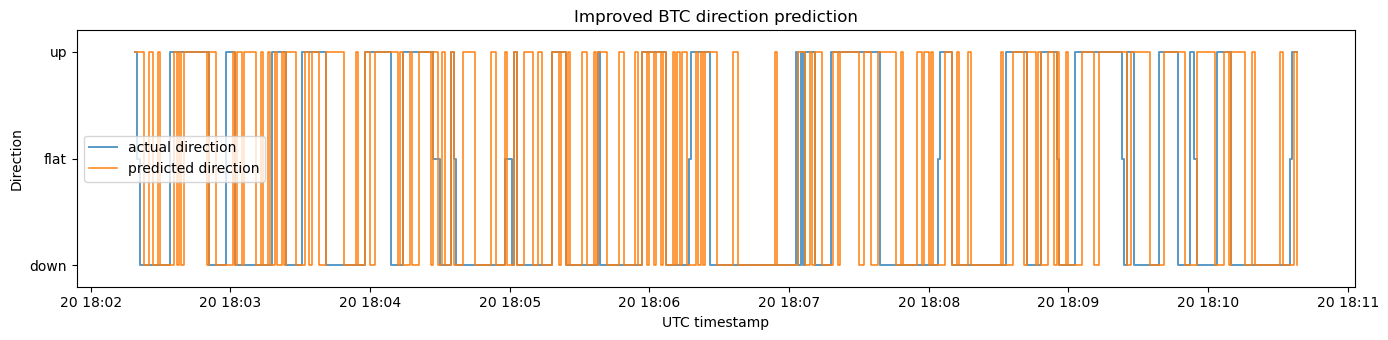

In [99]:
load_best_checkpoint(improved_direction_model, improved_direction_checkpoint_path, device)
improved_direction_prediction_frame = make_direction_prediction_frame(
    model=improved_direction_model,
    dataset=improved_direction_bundle['test_dataset'],
    device=device,
)
improved_direction_metrics, improved_direction_confusion = compute_direction_metrics(improved_direction_prediction_frame)

print('improved direction metrics')
print(improved_direction_metrics)
print(improved_direction_confusion)
print(improved_direction_prediction_frame[['timestamp_utc', 'target_direction', 'predicted_direction', 'prob_down', 'prob_flat', 'prob_up']].head())
plot_direction_predictions(improved_direction_prediction_frame, title='Improved BTC direction prediction', points=min(500, plot_points))
            
